<a href="https://colab.research.google.com/github/aniketsingh-netizen/Data_Analysis_week2/blob/main/week_3_assignments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Data Sample:
   Col_A          Date  Col_C  Col_D  Col_E
0     60  '2020/12/01'    110    130  409.1
1     60  '2020/12/02'    117    145  479.0
2     60  '2020/12/03'    103    135  340.0
3     45  '2020/12/04'    109    175  282.4
4     45  '2020/12/05'    117    148  406.0

Missing values per column before cleaning:
Col_A    0
Date     1
Col_C    0
Col_D    0
Col_E    2
dtype: int64

Cleaned and Processed Data Sample:
   Col_A          Date  Col_C  Col_D  Col_E  D_to_C_Ratio  Combined_Metric
0     60  '2020/12/01'    110    130  409.1      1.181818       483.481818
1     60  '2020/12/02'    117    145  479.0      1.239316       593.632479
2     60  '2020/12/03'    103    135  340.0      1.310680       445.631068
3     45  '2020/12/04'    109    175  282.4      1.605505       453.394495
4     45  '2020/12/05'    117    148  406.0      1.264957       513.572650


/tmp/ipykernel_2105/919122385.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Col_C'] = df_cleaned['Col_C'].fillna(df_cleaned['Col_C'].median())
/tmp/ipykernel_2105/919122385.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Col_D'] = df_cleaned['Col_D'].fillna(df_cleaned['Col_D'].median())


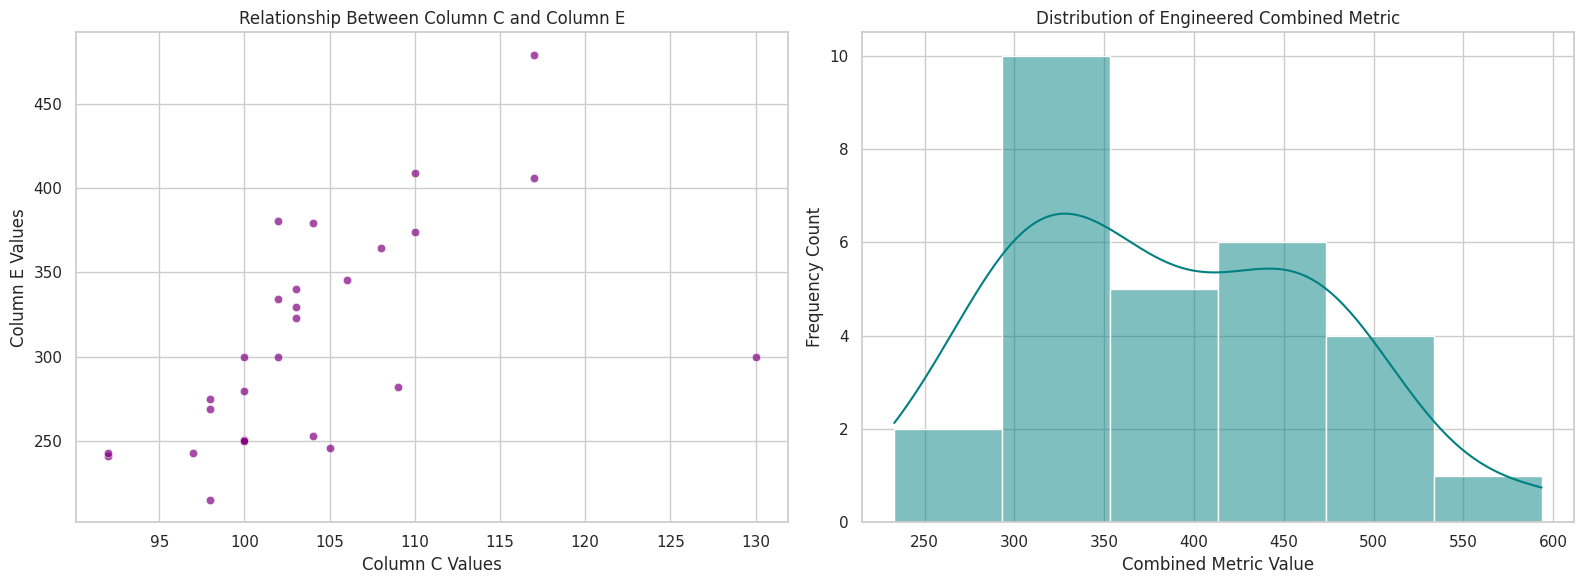

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "data.csv"
df = pd.read_csv(file_path, names=['Col_A', 'Date', 'Col_C', 'Col_D', 'Col_E'], header=0)

print("Original Data Sample:")
print(df.head())
print("\nMissing values per column before cleaning:")
print(df.isnull().sum())
df_cleaned = df.dropna(subset=['Date', 'Col_E'])
df_cleaned['Col_C'] = df_cleaned['Col_C'].fillna(df_cleaned['Col_C'].median())
df_cleaned['Col_D'] = df_cleaned['Col_D'].fillna(df_cleaned['Col_D'].median())

filtered_df = df_cleaned[df_cleaned['Col_E'] > 200].copy()
filtered_df['D_to_C_Ratio'] = filtered_df['Col_D'] / filtered_df['Col_C']
filtered_df['Combined_Metric'] = filtered_df['Col_E'] * filtered_df['D_to_C_Ratio']

print("\nCleaned and Processed Data Sample:")
print(filtered_df.head())
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(ax=axes[0], data=filtered_df, x='Col_C', y='Col_E', color='purple', alpha=0.7)
axes[0].set_title('Relationship Between Column C and Column E')
axes[0].set_xlabel('Column C Values')
axes[0].set_ylabel('Column E Values')
sns.histplot(ax=axes[1], data=filtered_df, x='Combined_Metric', kde=True, color='teal')
axes[1].set_title('Distribution of Engineered Combined Metric')
axes[1].set_xlabel('Combined Metric Value')
axes[1].set_ylabel('Frequency Count')

plt.tight_layout()
plt.show()